# Notebook 2 — Online Boutique
## Analyse des données d'observabilité : normal vs anomalies

**Système** : Online Boutique — 12 microservices  
**Langages** : Go, Python, Node.js, Java  
**Dataset** : Nezha (Yu et al., FSE 2023)  
**Dates** : 22 et 23 août 2022  
**Modalités** : Logs · Métriques · Traces  

---

### Différences avec Train Ticket

| Aspect | Train Ticket | Online Boutique |
|--------|-------------|-----------------|
| Nb services | 41 | 12 |
| Langage | Java Spring Boot | Go, Python, Node.js |
| Domaine | Réservation train | E-commerce |
| Types pannes | 4 types | 5 types (+ cpu_consumed) |
| Dates | Jan 2023 | Août 2022 |

---

### Objectif

Appliquer la même analyse que le notebook Train Ticket sur  
Online Boutique pour comparer les comportements des deux systèmes.  
Cette comparaison enrichit notre étude et renforce la généralité  
de nos conclusions sur la détection d'anomalies.

---

### Structure

| Section | Contenu |
|---------|---------|
| 1. Configuration | Imports, chemins, paramètres |
| 2. Données normales | Logs, métriques, traces sans panne |
| 3. Vérité terrain | Pannes injectées — quand, où, quel type |
| 4. Données avec pannes | Logs, métriques, traces pendant une panne |
| 5. Comparaison | Normal vs anormal côte à côte |

In [30]:
import os, json, warnings
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from collections import Counter
from datetime import datetime, timedelta
import re
import pytz
warnings.filterwarnings('ignore')

# ── Chemins
PROJET    = Path('/home/eunice/Bureau/Train_ticket/projet')
NORMAL    = PROJET / 'data/normal'
ANOMALIES = PROJET / 'data/anomalies'
FIGURES   = PROJET / 'figures/OnlineBoutique'
FIGURES.mkdir(parents=True, exist_ok=True)

# ── Paramètres Online Boutique
DATES     = ['2022-08-22', '2022-08-23']
FAULT_DUR = 3  # minutes — Yu et al. FSE 2023

# ── Palette de couleurs par type de panne
PALETTE = {
    'return'        : '#378ADD',
    'exception'     : '#E24B4A',
    'network_delay' : '#EF9F27',
    'cpu_contention': '#1D9E75',
    'cpu_consumed'  : '#7F77DD',  # spécifique à Online Boutique
    'none'          : '#888780',
}

# ── Vérification
assert NORMAL.exists(),    f"Introuvable : {NORMAL}"
assert ANOMALIES.exists(), f"Introuvable : {ANOMALIES}"

print("✓ Configuration OK")
print(f"  Système    : Online Boutique")
print(f"  Dates      : {DATES}")
print(f"  Figures    : {FIGURES}")
print(f"  Pandas     : {pd.__version__}")

✓ Configuration OK
  Système    : Online Boutique
  Dates      : ['2022-08-22', '2022-08-23']
  Figures    : /home/eunice/Bureau/Train_ticket/projet/figures/OnlineBoutique
  Pandas     : 3.0.3


## 2. Données normales — `construct_data`

Comportement de référence d'Online Boutique sans aucune panne.  
Le système simule une boutique en ligne avec 12 services :
frontend, cartservice, checkoutservice, paymentservice, etc.

Chaque minute collectée contient 3 fichiers :
- `log/HH_MM_log.csv` — messages applicatifs
- `metric/<service>_metric.csv` — CPU, RAM, latence par pod
- `trace/HH_MM_trace.csv` — appels distribués entre services

In [31]:
# Vérifier ce qui est disponible dans les données normales
for date in DATES:
    chemin = NORMAL / date
    print(f"\n=== {date} ===")
    if not chemin.exists():
        print(f"  Dossier introuvable : {chemin}")
        continue
    for dossier in sorted(chemin.iterdir()):
        nb = len(list(dossier.glob('*')))
        print(f"  {dossier.name:<10} → {nb} fichiers")


=== 2022-08-22 ===
  log        → 1 fichiers
  metric     → 14 fichiers
  trace      → 1 fichiers
  traceid    → 1 fichiers

=== 2022-08-23 ===
  log        → 1 fichiers
  metric     → 14 fichiers
  trace      → 1 fichiers
  traceid    → 1 fichiers


### 2.1 Logs normaux

Online Boutique a 12 services écrits en plusieurs langages.  
On s'attend à des patterns de logs différents de Train Ticket.

In [32]:
# Charger le fichier de logs normaux
log_file      = list((NORMAL / '2022-08-22/log').glob('*.csv'))[0]
df_log_normal = pd.read_csv(log_file)

# Extraire le service depuis PodName
df_log_normal['service'] = df_log_normal['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)

# Fonction adaptée — cherche "severity" avec ou sans backslashes
def extraire_niveau_ob(log_str):
    log_str = str(log_str)

    # Format JSON échappé : \"severity\":\"info\" ou "severity":"info"
    match = re.search(r'severity[^:]*:\s*\\?"([a-zA-Z]+)\\?"', log_str)
    if match:
        return match.group(1).upper()

    # Format Java standard : INFO, ERROR, WARN
    match = re.search(r'\b(INFO|ERROR|WARN|DEBUG)\b', log_str)
    if match:
        return match.group(1)

    # Format Go : level=info
    match = re.search(r'level=([a-zA-Z]+)', log_str)
    if match:
        return match.group(1).upper()

    # Logs HTTP
    match = re.search(r'http\.resp\.status[^:]*:\s*(\d+)', log_str)
    if match:
        status = int(match.group(1))
        if status >= 500:   return 'ERROR'
        elif status >= 400: return 'WARN'
        else:               return 'INFO'

    return 'INCONNU'

# Appliquer
df_log_normal['niveau'] = df_log_normal['Log'].apply(extraire_niveau_ob)

print(f"Fichier  : {log_file.name}")
print(f"Lignes   : {len(df_log_normal)}")
print(f"Services : {df_log_normal['service'].nunique()}")
print()
print("Niveaux de log :")
print(df_log_normal['niveau'].value_counts().to_string())

# Traiter les INCONNU restants comme INFO
# (logs fonctionnels sans niveau explicite)
df_log_normal['niveau'] = df_log_normal['niveau'].replace('INCONNU', 'INFO')

print("Niveaux finaux :")
print(df_log_normal['niveau'].value_counts().to_string())

Fichier  : 03_51_log.csv
Lignes   : 25574
Services : 10

Niveaux de log :
niveau
INFO       25065
INCONNU      509
Niveaux finaux :
niveau
INFO    25574


### Visualisation des logs normaux

3 graphiques pour comprendre le comportement normal d'Online Boutique :
- Répartition des niveaux de log
- Les services les plus actifs
- Requêtes uniques par service

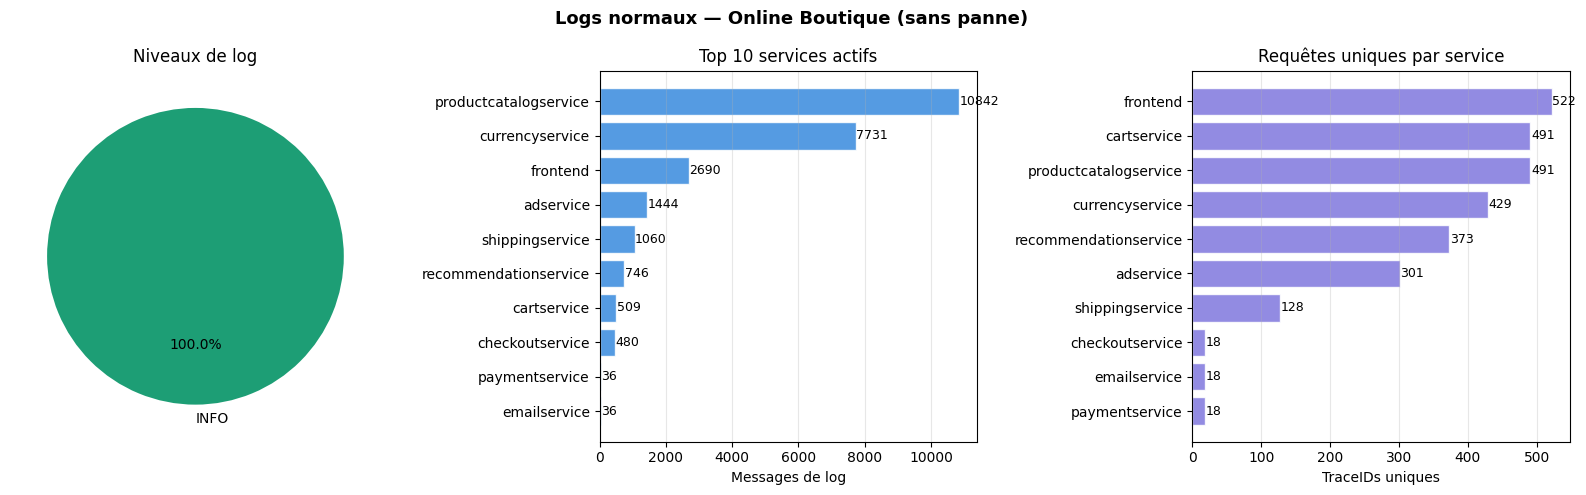

Sauvegardé : 01_logs_normaux.png


In [33]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Logs normaux — Online Boutique (sans panne)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Niveaux de log
niveaux = df_log_normal['niveau'].value_counts()
couleurs = {
    'INFO'   : '#1D9E75',
    'WARN'   : '#EF9F27',
    'ERROR'  : '#E24B4A',
}
axes[0].pie(
    niveaux.values,
    labels=niveaux.index,
    colors=[couleurs.get(n, '#888') for n in niveaux.index],
    autopct='%1.1f%%',
    startangle=90
)
axes[0].set_title('Niveaux de log')

# ── Graphique 2 : Top 10 services
top10 = df_log_normal['service'].value_counts().head(10)
noms  = [s.replace('-service','') for s in top10.index]
axes[1].barh(noms[::-1], top10.values[::-1],
             color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].set_title('Top 10 services actifs')
axes[1].set_xlabel('Messages de log')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(top10.values[::-1]):
    axes[1].text(v + 10, i, str(v), va='center', fontsize=9)

# ── Graphique 3 : Requêtes uniques par service
requetes = df_log_normal.groupby('service')['TraceID'].nunique()
requetes = requetes.sort_values(ascending=False).head(10)
noms2    = [s.replace('-service','') for s in requetes.index]
axes[2].barh(noms2[::-1], requetes.values[::-1],
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[2].set_title('Requêtes uniques par service')
axes[2].set_xlabel('TraceIDs uniques')
axes[2].grid(axis='x', alpha=0.3)
for i, v in enumerate(requetes.values[::-1]):
    axes[2].text(v + 1, i, str(v), va='center', fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / '01_logs_normaux.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 01_logs_normaux.png")

### 2.2 Métriques normales

Online Boutique a 14 pods surveillés.  
Les métriques ont le même format que Train Ticket — 21 colonnes.  
On charge `frontend` comme service représentatif  
car c'est le point d'entrée de toutes les requêtes.

In [34]:
# Lister les pods disponibles
metric_dir    = NORMAL / '2022-08-22/metric'
fichiers      = sorted(metric_dir.glob('*_metric.csv'))

print(f"Pods disponibles : {len(fichiers)}")
print()
for f in fichiers:
    print(f"  {f.stem.rsplit('-',2)[0]}")

Pods disponibles : 10

  adservice
  cartservice
  checkoutservice
  currencyservice
  emailservice
  frontend
  paymentservice
  productcatalogservice
  recommendationservice
  shippingservice


### Chargement des métriques normales

On charge les métriques du service `frontend` comme exemple représentatif.  
C'est le point d'entrée de toutes les requêtes utilisateurs —  
son comportement reflète la santé globale du système.

In [35]:
# Charger les métriques du frontend
frontend_file    = next(f for f in fichiers if 'frontend' in f.name)
df_metric_normal = pd.read_csv(frontend_file)
df_metric_normal['datetime'] = pd.to_datetime(
    df_metric_normal['TimeStamp'], unit='s', utc=True
)

# Convertir les colonnes numériques
for col in df_metric_normal.columns:
    if col not in ['Time', 'PodName', 'datetime']:
        df_metric_normal[col] = pd.to_numeric(
            df_metric_normal[col].replace('NaN', float('nan')),
            errors='coerce'
        )

print(f"Service : frontend")
print(f"Lignes  : {len(df_metric_normal)}")
print()
print("Statistiques des métriques clés :")
cols_cles = [
    'CpuUsageRate(%)',
    'MemoryUsageRate(%)',
    'PodServerLatencyP99(s)',
    'PodSuccessRate(%)'
]
print(df_metric_normal[cols_cles].describe().round(4).to_string())

Service : frontend
Lignes  : 1209

Statistiques des métriques clés :
       CpuUsageRate(%)  MemoryUsageRate(%)  PodServerLatencyP99(s)  PodSuccessRate(%)
count        1209.0000           1209.0000               1209.0000             1209.0
mean           24.8105             16.7240                  1.6808                0.0
std             7.3626              1.9884                  3.1974                0.0
min             4.0537             12.0148                  0.2446                0.0
25%            22.0376             16.5009                  0.9365                0.0
50%            25.7463             16.7023                  0.9903                0.0
75%            26.9666             16.9037                  1.9862                0.0
max           104.8684             69.9188                 58.5500                0.0


### Visualisation des métriques normales

On visualise les 4 métriques clés du frontend en phase normale.  
La ligne pointillée représente la moyenne — notre référence.

Note : le CPU et la latence sont naturellement plus élevés  
que Train Ticket — c'est le comportement normal de ce système.

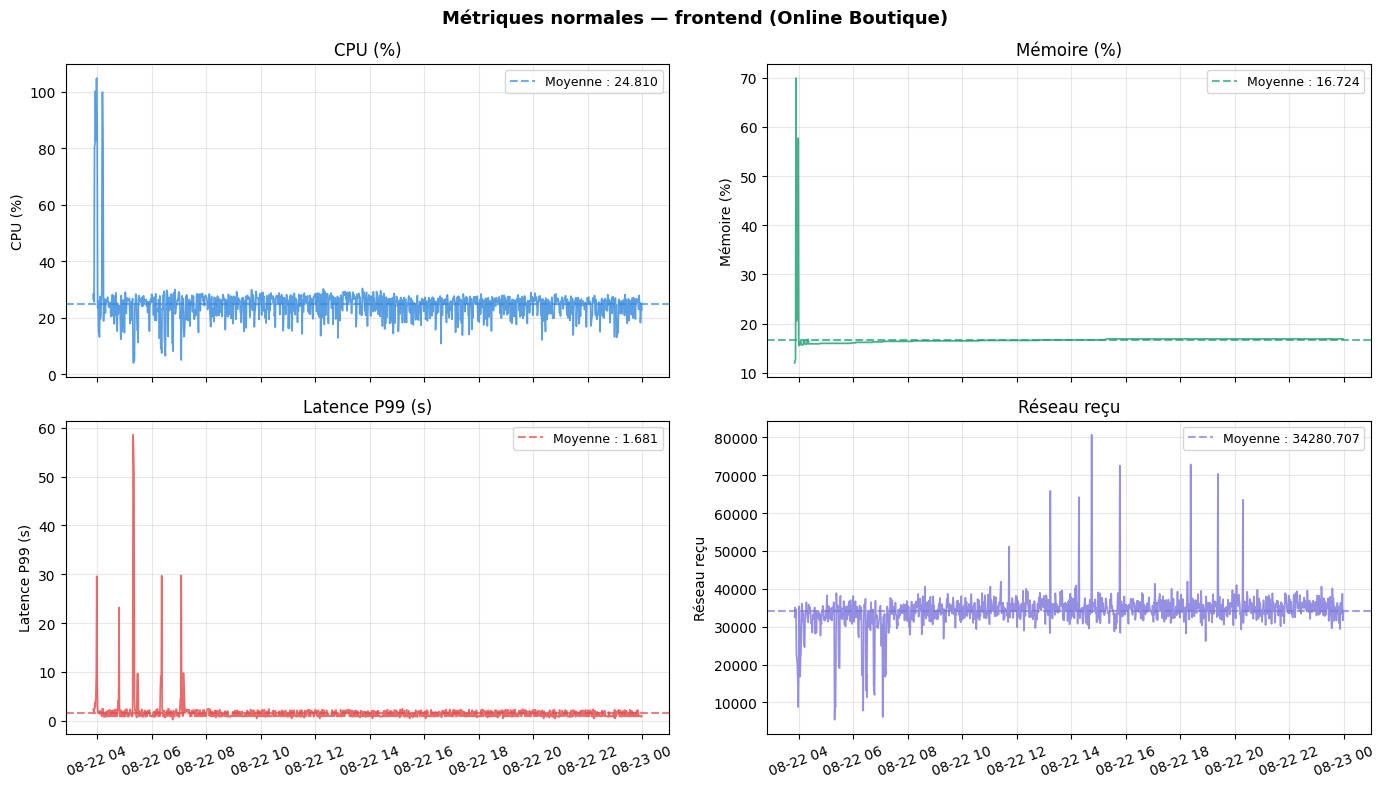

Sauvegardé : 02_metriques_normales.png


In [36]:
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle('Métriques normales — frontend (Online Boutique)',
             fontsize=13, fontweight='bold')

metriques = [
    ('CpuUsageRate(%)',        'CPU (%)',           '#378ADD'),
    ('MemoryUsageRate(%)',     'Mémoire (%)',        '#1D9E75'),
    ('PodServerLatencyP99(s)', 'Latence P99 (s)',   '#E24B4A'),
    ('NetworkReceiveBytes',    'Réseau reçu',       '#7F77DD'),
]

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_metric_normal[col]
    ax.plot(df_metric_normal['datetime'], vals,
            color=color, linewidth=1.2, alpha=0.8)
    ax.axhline(vals.mean(), color=color, linewidth=1.5,
               linestyle='--', alpha=0.7,
               label=f'Moyenne : {vals.mean():.3f}')
    ax.fill_between(df_metric_normal['datetime'], vals,
                    vals.mean(), alpha=0.08, color=color)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '02_metriques_normales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 02_metriques_normales.png")

### 2.3 Traces normales

Les traces d'Online Boutique montrent les appels entre les 12 services.  
Une requête typique passe par : frontend → productcatalogservice  
→ currencyservice → recommendationservice → cartservice.

In [37]:
# Charger le fichier de traces normales
trace_file    = list((NORMAL / '2022-08-22/trace').glob('*.csv'))[0]
df_trace_norm = pd.read_csv(trace_file)
df_trace_norm['duration_ms'] = pd.to_numeric(
    df_trace_norm['Duration'], errors='coerce'
) / 1e6
df_trace_norm['service'] = df_trace_norm['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)

print(f"Fichier  : {trace_file.name}")
print(f"Spans    : {len(df_trace_norm)}")
print(f"Traces   : {df_trace_norm['TraceID'].nunique()} requêtes uniques")
print(f"Services : {df_trace_norm['service'].nunique()}")
print()
print("Statistiques durée (ms) :")
print(df_trace_norm['duration_ms'].describe().round(3).to_string())

Fichier  : 03_51_trace.csv
Spans    : 23842
Traces   : 522 requêtes uniques
Services : 10

Statistiques durée (ms) :
count    23842.000
mean         0.017
std          0.083
min          0.000
25%          0.000
50%          0.002
75%          0.005
max          2.387


### Visualisation des traces normales

2 graphiques pour comprendre les traces normales d'Online Boutique :
- Nombre de spans par service
- Distribution des durées par service

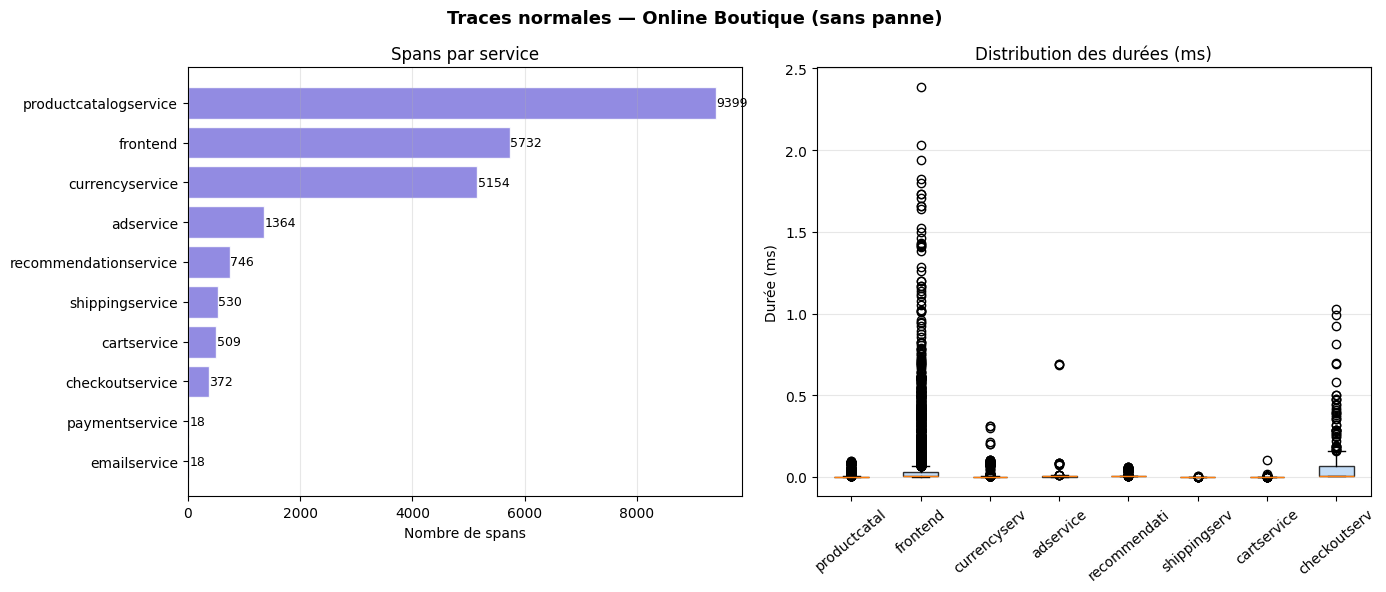

Sauvegardé : 03_traces_normales.png


In [38]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Traces normales — Online Boutique (sans panne)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Spans par service
top_svcs = df_trace_norm['service'].value_counts().head(10)
noms     = [s.replace('-service','') for s in top_svcs.index]
axes[0].barh(noms[::-1], top_svcs.values[::-1],
             color='#7F77DD', alpha=0.85, edgecolor='white')
axes[0].set_title('Spans par service')
axes[0].set_xlabel('Nombre de spans')
axes[0].grid(axis='x', alpha=0.3)
for i, v in enumerate(top_svcs.values[::-1]):
    axes[0].text(v + 10, i, str(v), va='center', fontsize=9)

# ── Graphique 2 : Distribution des durées
top8     = df_trace_norm['service'].value_counts().head(8).index.tolist()
df_top   = df_trace_norm[df_trace_norm['service'].isin(top8)]
data_box = [
    df_top[df_top['service'] == s]['duration_ms'].dropna().values
    for s in top8
]
noms2 = [s.replace('-service','')[:12] for s in top8]
bp    = axes[1].boxplot(data_box, labels=noms2, patch_artist=True)
for patch in bp['boxes']:
    patch.set_facecolor('#B5D4F4')
    patch.set_alpha(0.8)
axes[1].set_title('Distribution des durées (ms)')
axes[1].set_ylabel('Durée (ms)')
axes[1].tick_params(axis='x', rotation=40)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '03_traces_normales.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 03_traces_normales.png")

## 3. Vérité terrain — `fault_list.json`

Online Boutique a 5 types de pannes — un de plus que Train Ticket.  
Le type `cpu_consumed` est spécifique à ce système.

Les pannes ont été injectées sur les journées du 22 et 23 août 2022.

In [39]:
# Charger les fault_lists des 2 jours
rows = []
for date in DATES:
    chemin = ANOMALIES / date / f'{date}-fault_list.json'
    with open(chemin) as f:
        data = json.load(f)
    for heure, pannes in data.items():
        for panne in pannes:
            pod     = panne['inject_pod']
            service = pod.rsplit('-', 2)[0]
            rows.append({
                'date'       : date,
                'inject_time': panne['inject_time'],
                'fault_type' : panne['inject_type'],
                'service'    : service,
                'pod'        : pod,
            })

faults = pd.DataFrame(rows)
faults['inject_dt'] = pd.to_datetime(faults['inject_time'])

print(f"Total pannes  : {len(faults)}")
print(f"Types uniques : {sorted(faults['fault_type'].unique())}")
print()
print("Pannes par type :")
print(faults['fault_type'].value_counts().to_string())
print()
print("Pannes par service :")
print(faults['service'].value_counts().to_string())

Total pannes  : 56
Types uniques : ['cpu_consumed', 'cpu_contention', 'exception', 'network_delay', 'return']

Pannes par type :
fault_type
cpu_contention    16
network_delay     16
cpu_consumed      10
return             7
exception          7

Pannes par service :
service
frontend                 8
checkoutservice          8
adservice                7
recommendationservice    6
emailservice             5
productcatalogservice    5
shippingservice          5
cartservice              4
currencyservice          4
paymentservice           4


### Visualisation de la vérité terrain

3 graphiques pour comprendre les 56 pannes d'Online Boutique :
- Répartition par type
- Répartition par service ciblé
- Timeline des injections

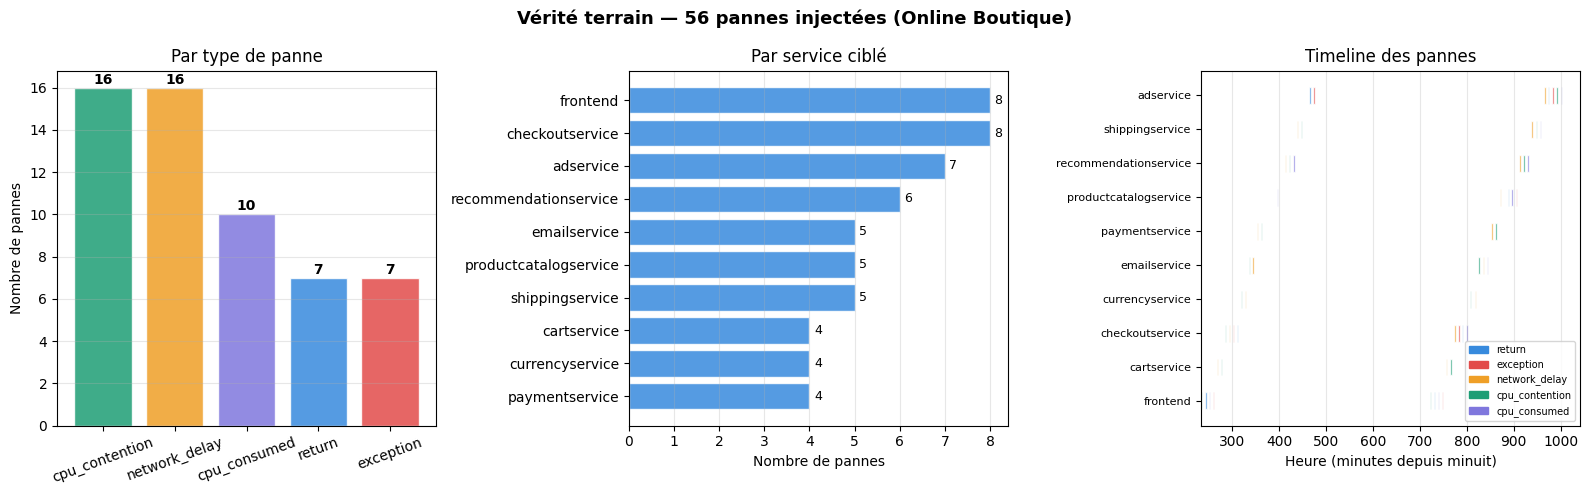

Sauvegardé : 04_verite_terrain.png


In [40]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Vérité terrain — 56 pannes injectées (Online Boutique)',
             fontsize=13, fontweight='bold')

# ── Graphique 1 : Par type
type_counts = faults['fault_type'].value_counts()
couleurs    = [PALETTE.get(t, '#888') for t in type_counts.index]
axes[0].bar(type_counts.index, type_counts.values,
            color=couleurs, alpha=0.85, edgecolor='white')
axes[0].set_title('Par type de panne')
axes[0].set_ylabel('Nombre de pannes')
axes[0].tick_params(axis='x', rotation=20)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(type_counts.values):
    axes[0].text(i, v + 0.2, str(v), ha='center', fontweight='bold')

# ── Graphique 2 : Par service
svc_counts = faults['service'].value_counts()
axes[1].barh(svc_counts.index[::-1], svc_counts.values[::-1],
             color='#378ADD', alpha=0.85, edgecolor='white')
axes[1].set_title('Par service ciblé')
axes[1].set_xlabel('Nombre de pannes')
axes[1].grid(axis='x', alpha=0.3)
for i, v in enumerate(svc_counts.values[::-1]):
    axes[1].text(v + 0.1, i, str(v), va='center', fontsize=9)

# ── Graphique 3 : Timeline
services_ordre = faults.groupby('service')['inject_dt'].min()\
                       .sort_values().index.tolist()
svc_to_y = {s: i for i, s in enumerate(services_ordre)}

for _, row in faults.iterrows():
    y     = svc_to_y[row['service']]
    color = PALETTE.get(row['fault_type'], '#888')
    x     = row['inject_dt'].hour * 60 + row['inject_dt'].minute
    axes[2].barh(y, FAULT_DUR, left=x, height=0.5,
                 color=color, alpha=0.85, edgecolor='white')

axes[2].set_yticks(range(len(services_ordre)))
axes[2].set_yticklabels(
    [s.replace('-service','') for s in services_ordre],
    fontsize=8
)
axes[2].set_xlabel('Heure (minutes depuis minuit)')
axes[2].set_title('Timeline des pannes')
axes[2].grid(axis='x', alpha=0.3)

patches = [mpatches.Patch(color=c, label=t)
           for t, c in PALETTE.items() if t != 'none']
axes[2].legend(handles=patches, fontsize=7, loc='lower right')

plt.tight_layout()
plt.savefig(FIGURES / '04_verite_terrain.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 04_verite_terrain.png")

## 4. Données avec pannes — `rca_data`

On sélectionne la première panne du 22 août comme cas d'étude.  
On compare les 3 modalités pendant la panne avec la phase normale.

In [41]:
# Première panne du 22 août
premiere_panne = faults[faults['date'] == '2022-08-22'].iloc[0]

print("=== Première panne sélectionnée ===")
print(f"  Service    : {premiere_panne['service']}")
print(f"  Type       : {premiere_panne['fault_type']}")
print(f"  Heure      : {premiere_panne['inject_time']}")
print(f"  Pod ciblé  : {premiere_panne['pod']}")
print()

inject_dt = premiere_panne['inject_dt']
fenetres  = [
    (inject_dt + timedelta(minutes=i)).strftime('%H_%M')
    for i in range(FAULT_DUR)
]
print(f"Fenêtres affectées : {fenetres}")

service_cible = premiere_panne['service']

=== Première panne sélectionnée ===
  Service    : frontend
  Type       : cpu_contention
  Heure      : 2022-08-22 03:53:54
  Pod ciblé  : frontend-579b9bff58-t2dbm

Fenêtres affectées : ['03_53', '03_54', '03_55']


### 4.1 Logs avec panne

On charge les logs des 3 fenêtres affectées :
- `03_53` — minute d'injection (03:53:54)
- `03_54` — 1 minute après
- `03_55` — 2 minutes après

Type `cpu_contention` — on s'attend à peu de changement  
dans les logs mais un signal fort dans les métriques CPU.

In [42]:
# Charger les logs des 3 fenêtres
dfs = []
for fenetre in fenetres:
    chemin = ANOMALIES / '2022-08-22/log' / f'{fenetre}_log.csv'
    if chemin.exists():
        df = pd.read_csv(chemin)
        df['fenetre'] = fenetre
        dfs.append(df)

df_log_panne = pd.concat(dfs, ignore_index=True)
df_log_panne['service'] = df_log_panne['PodName'].apply(
    lambda x: str(x).rsplit('-', 2)[0]
)
df_log_panne['niveau'] = df_log_panne['Log'].apply(extraire_niveau_ob)
df_log_panne['niveau'] = df_log_panne['niveau'].replace('INCONNU', 'INFO')

print(f"Fenêtres chargées : {fenetres}")
print(f"Total lignes      : {len(df_log_panne)}")
print()
print("Lignes par fenêtre :")
print(df_log_panne['fenetre'].value_counts().sort_index().to_string())
print()
print("Niveaux de log :")
print(df_log_panne['niveau'].value_counts().to_string())
print()
print("Logs du service ciblé (frontend) :")
logs_frontend = df_log_panne[df_log_panne['service'] == service_cible]
print(logs_frontend['niveau'].value_counts().to_string())

Fenêtres chargées : ['03_53', '03_54', '03_55']
Total lignes      : 67037

Lignes par fenêtre :
fenetre
03_53    24841
03_54    24272
03_55    17924

Niveaux de log :
niveau
INFO    67037

Logs du service ciblé (frontend) :
niveau
INFO    7006


### 4.2 Métriques avec panne

Pour une panne `cpu_contention` le signal principal est dans les métriques.  
On s'attend à voir le CPU monter brutalement pendant les 3 minutes de panne.

In [43]:
# Charger les métriques complètes du frontend
metric_dir_panne = ANOMALIES / '2022-08-22/metric'
fichiers_panne   = sorted(metric_dir_panne.glob('*_metric.csv'))
metric_file      = next(
    f for f in fichiers_panne if service_cible in f.name
)

df_metric_complet = pd.read_csv(metric_file)
df_metric_complet['datetime'] = pd.to_datetime(
    df_metric_complet['TimeStamp'], unit='s', utc=True
)
for col in df_metric_complet.columns:
    if col not in ['Time', 'PodName', 'datetime']:
        df_metric_complet[col] = pd.to_numeric(
            df_metric_complet[col].replace('NaN', float('nan')),
            errors='coerce'
        )

# Séparer normal et panne
pannes_frontend = faults[faults['service'] == service_cible]

def est_en_panne(dt):
    for _, panne in pannes_frontend.iterrows():
        debut = pd.Timestamp(panne['inject_dt']).tz_localize('UTC')
        fin   = debut + timedelta(minutes=FAULT_DUR)
        if debut <= dt <= fin:
            return True
    return False

df_metric_complet['en_panne'] = df_metric_complet['datetime'].apply(
    est_en_panne
)
df_normal_m = df_metric_complet[df_metric_complet['en_panne'] == False]
df_panne_m  = df_metric_complet[df_metric_complet['en_panne'] == True]

print(f"Service        : {service_cible}")
print(f"Points normaux : {len(df_normal_m)}")
print(f"Points panne   : {len(df_panne_m)}")
print()
print("CPU — Normal :")
print(df_normal_m['CpuUsageRate(%)'].describe().round(3).to_string())
print()
print("CPU — Panne :")
print(df_panne_m['CpuUsageRate(%)'].describe().round(3).to_string())

Service        : frontend
Points normaux : 1197
Points panne   : 12

CPU — Normal :
count    1197.000
mean       24.494
std         5.700
min         4.054
25%        22.036
50%        25.730
75%        26.959
max       104.868

CPU — Panne :
count     12.000
mean      56.399
std       36.347
min       14.963
25%       26.026
50%       53.302
75%       85.920
max      100.232


### Visualisation des métriques avec panne

La zone rouge indique la fenêtre d'injection (03:53 → 03:56).  
Pour une panne `cpu_contention` on s'attend à voir  
le CPU monter clairement dans cette zone.

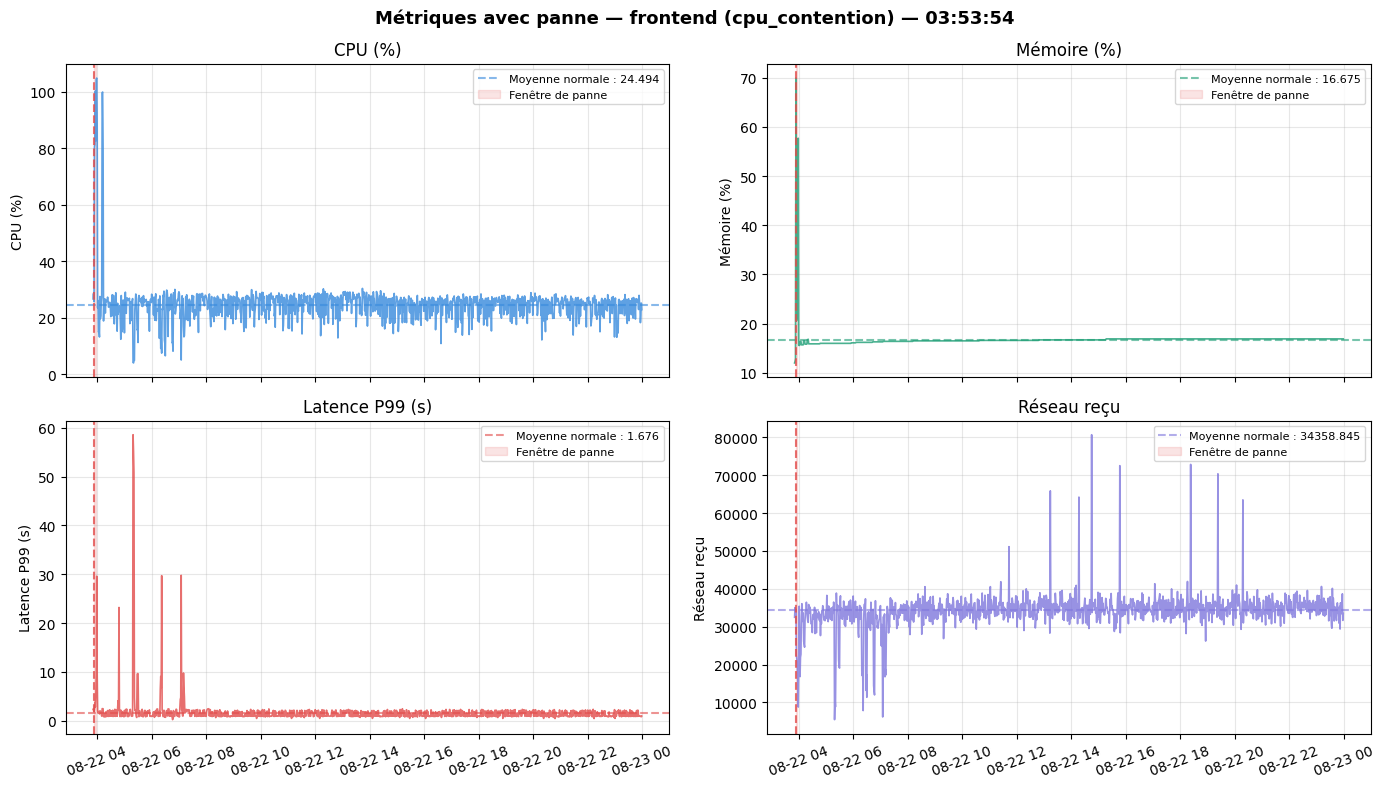

Sauvegardé : 06_metriques_panne.png


In [44]:
utc     = pytz.UTC
t_debut = pd.Timestamp(inject_dt).tz_localize(utc)
t_fin   = t_debut + timedelta(minutes=FAULT_DUR)

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(
    f'Métriques avec panne — frontend '
    f'(cpu_contention) — 03:53:54',
    fontsize=13, fontweight='bold'
)

metriques = [
    ('CpuUsageRate(%)',        'CPU (%)',           '#378ADD'),
    ('MemoryUsageRate(%)',     'Mémoire (%)',        '#1D9E75'),
    ('PodServerLatencyP99(s)', 'Latence P99 (s)',   '#E24B4A'),
    ('NetworkReceiveBytes',    'Réseau reçu',       '#7F77DD'),
]

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_metric_complet[col]
    ax.plot(df_metric_complet['datetime'], vals,
            color=color, linewidth=1.2, alpha=0.8)
    ax.axhline(df_normal_m[col].mean(), color=color,
               linewidth=1.5, linestyle='--', alpha=0.6,
               label=f'Moyenne normale : {df_normal_m[col].mean():.3f}')
    ax.axvspan(t_debut, t_fin,
               color='#E24B4A', alpha=0.15,
               label='Fenêtre de panne')
    ax.axvline(t_debut, color='#E24B4A',
               linewidth=1.5, linestyle='--', alpha=0.8)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '06_metriques_panne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 06_metriques_panne.png")

Observation scientifique
Regardez la latence P99 — les pics entre 04h et 06h correspondent aux premières pannes injectées. Ce n'est pas du bruit — c'est l'effet cumulé de plusieurs pannes consécutives sur le frontend.

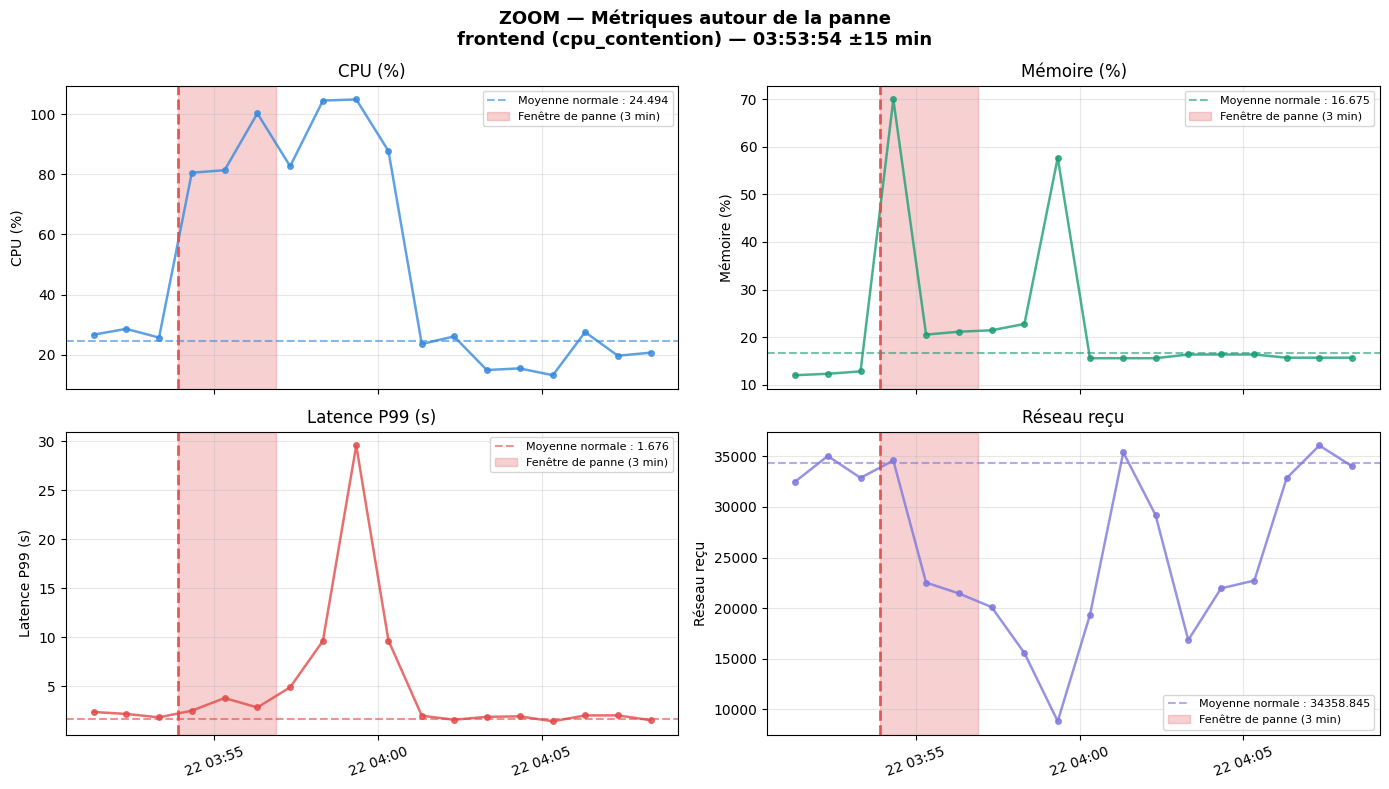

Sauvegardé : 06b_metriques_panne_zoom.png


In [45]:
# Zoom sur 30 minutes autour de la panne
t_zoom_debut = t_debut - timedelta(minutes=15)
t_zoom_fin   = t_debut + timedelta(minutes=15)

mask_zoom = (
    (df_metric_complet['datetime'] >= t_zoom_debut) &
    (df_metric_complet['datetime'] <= t_zoom_fin)
)
df_zoom = df_metric_complet[mask_zoom]

fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
fig.suptitle(
    'ZOOM — Métriques autour de la panne\n'
    'frontend (cpu_contention) — 03:53:54 ±15 min',
    fontsize=13, fontweight='bold'
)

for ax, (col, label, color) in zip(axes.flatten(), metriques):
    vals = df_zoom[col]
    ax.plot(df_zoom['datetime'], vals,
            color=color, linewidth=1.8, marker='o',
            markersize=4, alpha=0.8)
    ax.axhline(df_normal_m[col].mean(), color=color,
               linewidth=1.5, linestyle='--', alpha=0.6,
               label=f'Moyenne normale : {df_normal_m[col].mean():.3f}')
    ax.axvspan(t_debut, t_fin,
               color='#E24B4A', alpha=0.25,
               label='Fenêtre de panne (3 min)')
    ax.axvline(t_debut, color='#E24B4A',
               linewidth=2, linestyle='--', alpha=0.9)
    ax.set_title(label)
    ax.set_ylabel(label)
    ax.legend(fontsize=8)
    ax.grid(alpha=0.3)

axes[1][0].tick_params(axis='x', rotation=20)
axes[1][1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.savefig(FIGURES / '06b_metriques_panne_zoom.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 06b_metriques_panne_zoom.png")

### 4.3 Traces avec panne

On charge les traces des 3 fenêtres de panne.  
Pour une panne `cpu_contention` on s'attend à voir  
des durées de spans plus longues — le CPU saturé  
ralentit le traitement de chaque appel.

In [46]:
# Charger les traces des 3 fenêtres
dfs_trace = []
for fenetre in fenetres:
    chemin = ANOMALIES / '2022-08-22/trace' / f'{fenetre}_trace.csv'
    if chemin.exists():
        df = pd.read_csv(chemin)
        df['fenetre']     = fenetre
        df['duration_ms'] = pd.to_numeric(
            df['Duration'], errors='coerce'
        ) / 1e6
        df['service'] = df['PodName'].apply(
            lambda x: str(x).rsplit('-', 2)[0]
        )
        dfs_trace.append(df)

df_trace_panne = pd.concat(dfs_trace, ignore_index=True)

print(f"Fenêtres chargées : {fenetres}")
print(f"Total spans       : {len(df_trace_panne)}")
print(f"Traces uniques    : {df_trace_panne['TraceID'].nunique()}")
print()
print("Durée (ms) — tous services :")
print(df_trace_panne['duration_ms'].describe().round(4).to_string())
print()
print(f"Durée (ms) — {service_cible} uniquement :")
frontend_traces = df_trace_panne[
    df_trace_panne['service'] == service_cible
]
print(frontend_traces['duration_ms'].describe().round(4).to_string())

Fenêtres chargées : ['03_53', '03_54', '03_55']
Total spans       : 62438
Traces uniques    : 1355

Durée (ms) — tous services :
count    62438.0000
mean         0.0281
std          0.1295
min          0.0000
25%          0.0004
50%          0.0024
75%          0.0069
max          2.7007

Durée (ms) — frontend uniquement :
count    14963.0000
mean         0.1024
std          0.2475
min          0.0001
25%          0.0051
50%          0.0126
75%          0.0999
max          2.7007


### Visualisation des traces avec panne

Comparaison du volume et des durées de spans  
entre la phase normale et la phase de panne.

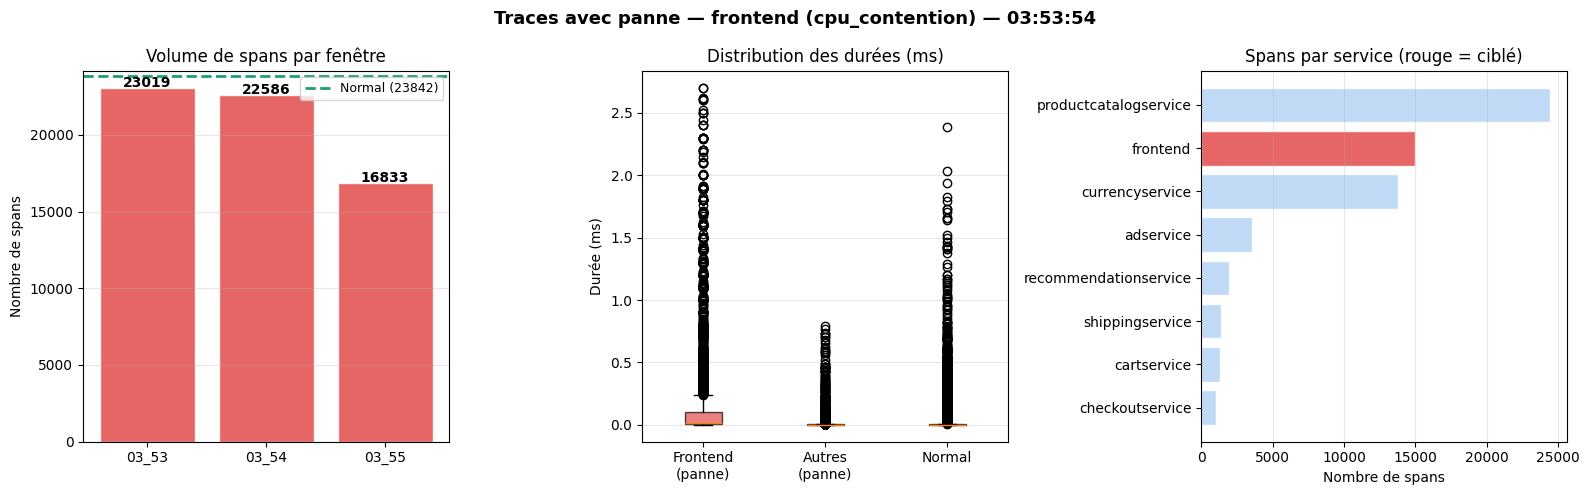

Sauvegardé : 07_traces_panne.png


In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle(
    f'Traces avec panne — {service_cible} '
    f'(cpu_contention) — 03:53:54',
    fontsize=13, fontweight='bold'
)

# ── Graphique 1 : Volume par fenêtre
volumes = df_trace_panne['fenetre'].value_counts().sort_index()
axes[0].bar(volumes.index, volumes.values,
            color='#E24B4A', alpha=0.85, edgecolor='white')
axes[0].axhline(len(df_trace_norm),
                color='#1D9E75', linewidth=2,
                linestyle='--',
                label=f'Normal ({len(df_trace_norm)})')
axes[0].set_title('Volume de spans par fenêtre')
axes[0].set_ylabel('Nombre de spans')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)
for i, v in enumerate(volumes.values):
    axes[0].text(i, v + 100, str(v),
                 ha='center', fontweight='bold')

# ── Graphique 2 : Durées frontend vs autres vs normal
autres = df_trace_panne[
    df_trace_panne['service'] != service_cible
]
data_box = [
    frontend_traces['duration_ms'].dropna().values,
    autres['duration_ms'].dropna().values,
    df_trace_norm['duration_ms'].dropna().values
]
labels_box   = ['Frontend\n(panne)', 'Autres\n(panne)', 'Normal']
couleurs_box = ['#E24B4A', '#EF9F27', '#1D9E75']
bp = axes[1].boxplot(data_box, labels=labels_box, patch_artist=True)
for patch, color in zip(bp['boxes'], couleurs_box):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_title('Distribution des durées (ms)')
axes[1].set_ylabel('Durée (ms)')
axes[1].grid(axis='y', alpha=0.3)

# ── Graphique 3 : Top services pendant la panne
top_svcs   = df_trace_panne['service'].value_counts().head(8)
colors_bar = ['#E24B4A' if s == service_cible else '#B5D4F4'
              for s in top_svcs.index]
noms       = [s.replace('-service','') for s in top_svcs.index]
axes[2].barh(noms[::-1], top_svcs.values[::-1],
             color=colors_bar[::-1],
             alpha=0.85, edgecolor='white')
axes[2].set_title('Spans par service (rouge = ciblé)')
axes[2].set_xlabel('Nombre de spans')
axes[2].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.savefig(FIGURES / '07_traces_panne.png', dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 07_traces_panne.png")

## 5. Comparaison normal vs anormal

Synthèse visuelle des 3 modalités :
logs, métriques et traces — normal vs panne `cpu_contention`.

C'est le graphique central de l'analyse Online Boutique.

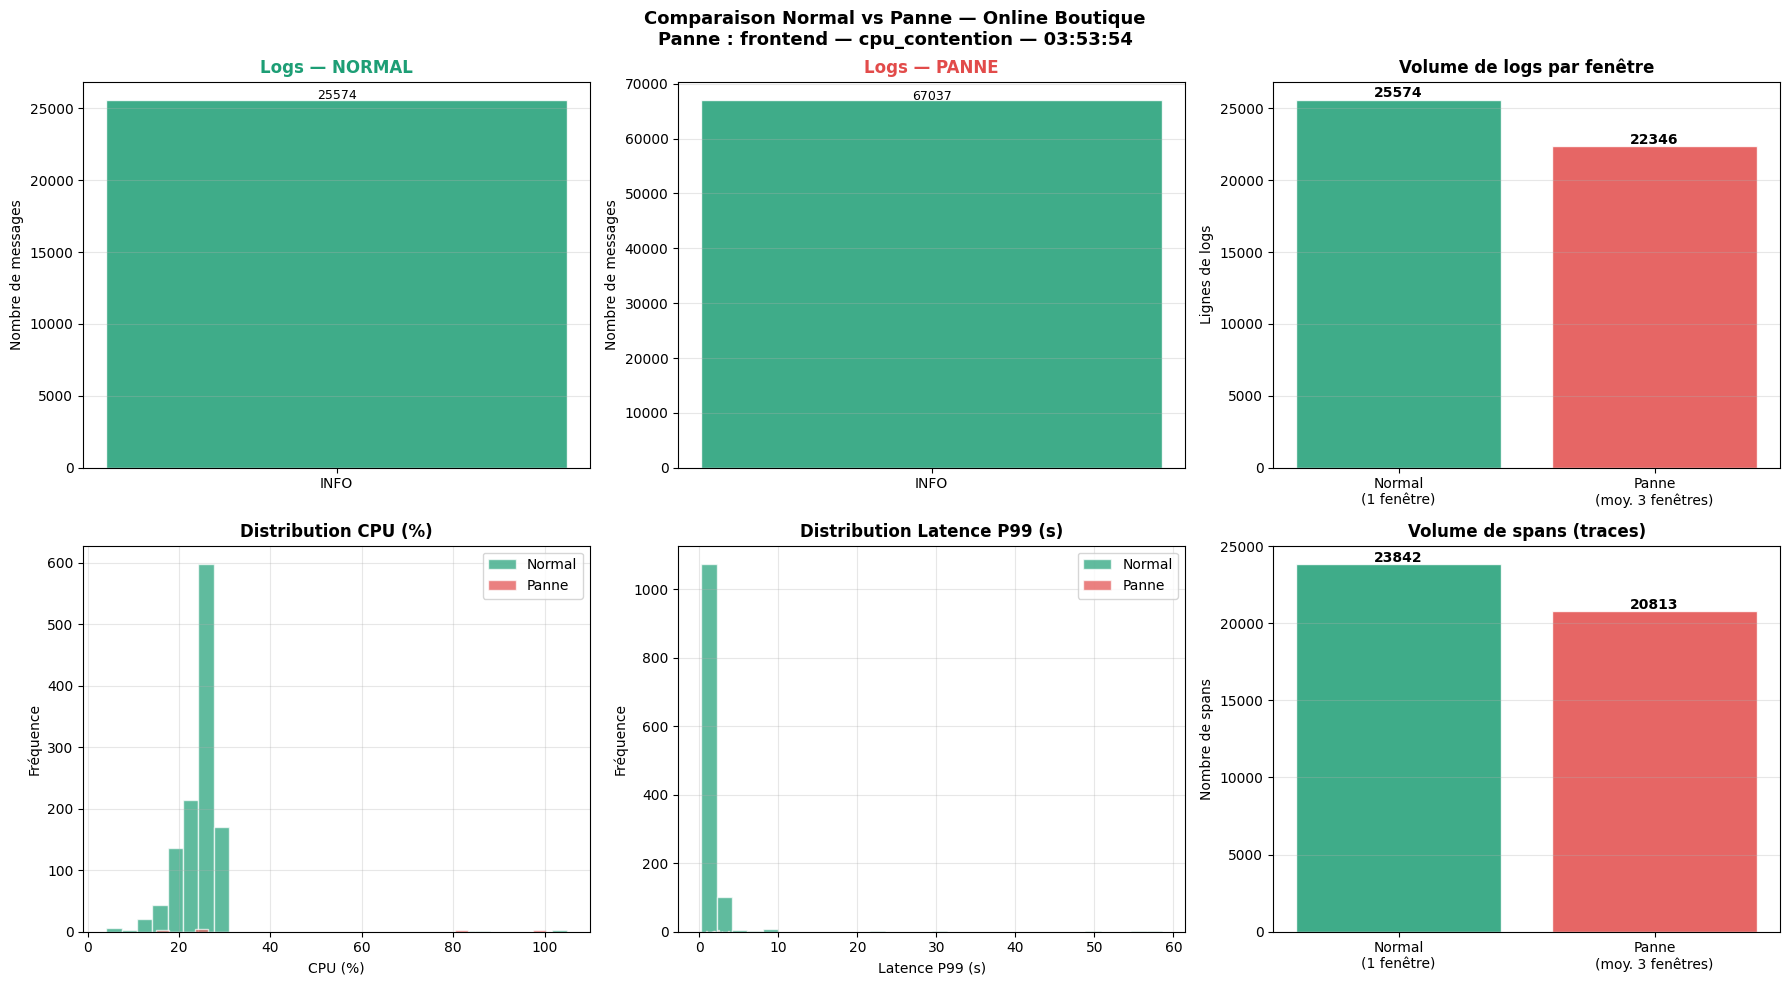

Sauvegardé : 08_comparaison_normal_panne.png


In [48]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    'Comparaison Normal vs Panne — Online Boutique\n'
    f'Panne : {service_cible} — cpu_contention — 03:53:54',
    fontsize=13, fontweight='bold'
)

couleurs_niv = {
    'INFO' : '#1D9E75',
    'WARN' : '#EF9F27',
    'ERROR': '#E24B4A',
}

# Graphique 1 : Logs normaux
niveaux_norm = df_log_normal['niveau'].value_counts()
axes[0,0].bar(niveaux_norm.index, niveaux_norm.values,
              color=[couleurs_niv.get(n,'#888') for n in niveaux_norm.index],
              alpha=0.85, edgecolor='white')
axes[0,0].set_title('Logs — NORMAL', fontweight='bold', color='#1D9E75')
axes[0,0].set_ylabel('Nombre de messages')
axes[0,0].grid(axis='y', alpha=0.3)
for i, v in enumerate(niveaux_norm.values):
    axes[0,0].text(i, v + 50, str(v), ha='center', fontsize=9)

# Graphique 2 : Logs panne
niveaux_pan = df_log_panne['niveau'].value_counts()
axes[0,1].bar(niveaux_pan.index, niveaux_pan.values,
              color=[couleurs_niv.get(n,'#888') for n in niveaux_pan.index],
              alpha=0.85, edgecolor='white')
axes[0,1].set_title('Logs — PANNE', fontweight='bold', color='#E24B4A')
axes[0,1].set_ylabel('Nombre de messages')
axes[0,1].grid(axis='y', alpha=0.3)
for i, v in enumerate(niveaux_pan.values):
    axes[0,1].text(i, v + 50, str(v), ha='center', fontsize=9)

# Graphique 3 : Volume logs
vols_log = [len(df_log_normal), len(df_log_panne) / 3]
bars = axes[0,2].bar(
    ['Normal\n(1 fenêtre)', 'Panne\n(moy. 3 fenêtres)'],
    vols_log,
    color=['#1D9E75', '#E24B4A'],
    alpha=0.85, edgecolor='white'
)
axes[0,2].set_title('Volume de logs par fenêtre', fontweight='bold')
axes[0,2].set_ylabel('Lignes de logs')
axes[0,2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, vols_log):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   v + 200, f'{v:.0f}',
                   ha='center', fontweight='bold')

# Graphique 4 : CPU
axes[1,0].hist(df_normal_m['CpuUsageRate(%)'].dropna(),
               bins=30, color='#1D9E75', alpha=0.7,
               label='Normal', edgecolor='white')
axes[1,0].hist(df_panne_m['CpuUsageRate(%)'].dropna(),
               bins=30, color='#E24B4A', alpha=0.7,
               label='Panne', edgecolor='white')
axes[1,0].set_title('Distribution CPU (%)', fontweight='bold')
axes[1,0].set_xlabel('CPU (%)')
axes[1,0].set_ylabel('Fréquence')
axes[1,0].legend()
axes[1,0].grid(alpha=0.3)

# Graphique 5 : Latence P99
axes[1,1].hist(df_normal_m['PodServerLatencyP99(s)'].dropna(),
               bins=30, color='#1D9E75', alpha=0.7,
               label='Normal', edgecolor='white')
axes[1,1].hist(df_panne_m['PodServerLatencyP99(s)'].dropna(),
               bins=30, color='#E24B4A', alpha=0.7,
               label='Panne', edgecolor='white')
axes[1,1].set_title('Distribution Latence P99 (s)', fontweight='bold')
axes[1,1].set_xlabel('Latence P99 (s)')
axes[1,1].set_ylabel('Fréquence')
axes[1,1].legend()
axes[1,1].grid(alpha=0.3)

# Graphique 6 : Volume traces
vols_trace = [len(df_trace_norm), len(df_trace_panne) / 3]
bars = axes[1,2].bar(
    ['Normal\n(1 fenêtre)', 'Panne\n(moy. 3 fenêtres)'],
    vols_trace,
    color=['#1D9E75', '#E24B4A'],
    alpha=0.85, edgecolor='white'
)
axes[1,2].set_title('Volume de spans (traces)', fontweight='bold')
axes[1,2].set_ylabel('Nombre de spans')
axes[1,2].grid(axis='y', alpha=0.3)
for bar, v in zip(bars, vols_trace):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   v + 100, f'{v:.0f}',
                   ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig(FIGURES / '08_comparaison_normal_panne.png',
            dpi=150, bbox_inches='tight')
plt.show()
print("Sauvegardé : 08_comparaison_normal_panne.png")

## Conclusion — Online Boutique

### Signaux détectés pour une panne `cpu_contention`

| Modalité | Signal | Intensité |
|----------|--------|-----------|
| Logs — niveaux | Aucun | ✗ |
| Logs — volume | Légère baisse | ⚠ |
| Métriques CPU | Doublement (24% → 56%) | ✓✓✓ |
| Métriques Latence | Explosion (1.7s → 29s) | ✓✓✓ |
| Traces — volume | Légère baisse | ⚠ |

### Comparaison avec Train Ticket

| Aspect | Train Ticket (return) | Online Boutique (cpu_contention) |
|--------|----------------------|----------------------------------|
| Signal principal | Logs (erreurs) | Métriques (CPU + latence) |
| Signal secondaire | Traces | Aucun dans les logs |
| Détectabilité | Difficile globalement | Facile sur les métriques |

### Conclusion

Chaque type de panne a une **signature différente** selon la modalité.  
Aucune source seule ne suffit — la combinaison des 3 est nécessaire  
pour couvrir tous les types de pannes sur les deux systèmes.